In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix

In [97]:
df = pd.read_csv("D:\AI\code\heart_disease_training.csv")
df.head(5)

,Patient_ID,Age,Gender,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Cholesterol,BMI,Heart_Rate,Body_Temp_F,Blood_Sugar,Heart_Disease
0,P0001,67,Male,85,97,266,34.5,45,98.8,60,0
1,P0002,43,Male,159,93,181,29.1,66,96.7,192,1
2,P0003,44,Female,149,82,230,23.3,66,97.1,60,1
3,P0004,73,Female,103,74,206,23.3,60,99.0,79,1
4,P0005,47,Female,104,92,242,39.1,86,96.7,123,1


In [69]:
X = df[['Age', 'Blood_Pressure_Systolic',
       'Blood_Pressure_Diastolic', 'Cholesterol', 'BMI', 'Heart_Rate',
       'Body_Temp_F', 'Blood_Sugar']]
Y = df['Heart_Disease']

x_train, x_test, y_train, y_test = train_test_split(
    X,Y,
    test_size = 0.25,
    random_state=42
)

model = LogisticRegression(max_iter = 1000)
model.fit(x_train, y_train)
y_predict = model.predict(x_test)

In [86]:
# Confusion Matrix of Logistic Regression and other values.
cm = confusion_matrix(y_predict, y_test)
acc = accuracy_score(y_predict, y_test)
pre = precision_score(y_predict, y_test)
recall = recall_score(y_predict, y_test)
f1 = f1_score(y_predict, y_test)

print("Confusion Matrix : \n", cm)
print()
print("Accuracy Score : ", round(acc,2))
print("precision Score : ", round(pre,2))
print("Recall Score : ", round(recall,2))
print("F1 Score : ", round(f1, 2))

Confusion Matrix : 
 [[116  46]
 [ 30  58]]

Accuracy Score :  0.7
precision Score :  0.56
Recall Score :  0.66
F1 Score :  0.6


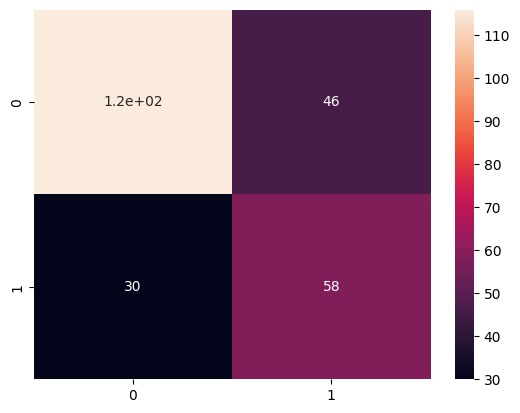

In [96]:
sns.heatmap(cm, annot = True)
plt.show()

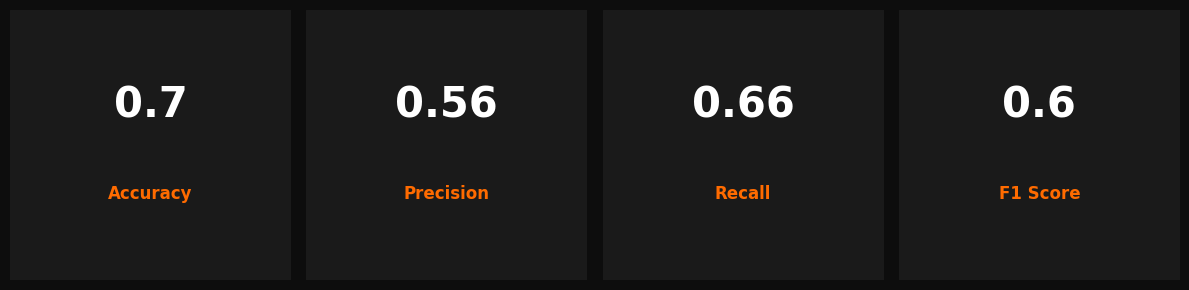

In [106]:
# Setup data
metrics = {"Accuracy": round(acc,2), "Precision": round(pre,2), "Recall": round(recall,2), "F1 Score": round(f1,2)}
fig, axes = plt.subplots(1, 4, figsize=(12, 3), facecolor='#0D0D0D')

for ax, (name, val) in zip(axes, metrics.items()):
    # Create dark card
    ax.add_patch(plt.Rectangle((0, 0), 1, 1, transform=ax.transAxes, color='#1A1A1A'))
    
    # Add value text
    ax.text(0.5, 0.6, str(val), fontsize=30, fontweight='bold', color='white', ha='center')
    
    # Add label text
    ax.text(0.5, 0.3, name, fontsize=12, color='#FF6B00', fontweight='bold', ha='center')
    
    ax.axis('off')

plt.tight_layout()
plt.show()